# Exercício: SARIMA no comércio varejista brasileiro

**UF de interesse: Pernambuco (PE)**

**Autor:** João Felipe Farias  
**Disciplina:** Financial Analytics — Insper

## Sobre o exercício

A base é a **PMC** (Pesquisa Mensal do Comércio) do IBGE: índice de volume de vendas no **comércio varejista ampliado** (inclui veículos e materiais de construção), por **Unidade da Federação**, mensal de jan/2004 em diante. Base 2022 = 100, **sem ajuste sazonal**.

Roteiro:

1. Análise descritiva (linha, ACF, PACF, diferenciação) e diagnóstico de tendência/sazonalidade.
2. Testes de raiz unitária (ADF, KPSS) e estimativa de `ndiffs`/`nsdiffs`.
3. Ajuste de SARIMA via `AutoARIMA(season_length=12)`.
4. Diagnóstico dos resíduos.
5. Previsão de 24 meses à frente, com intervalos de 80% e 95%.
6. Discussão dos resultados.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from pmdarima.arima.utils import ndiffs, nsdiffs

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Carregando a base PMC

A base já foi pré-processada para conter apenas as colunas relevantes, e já no formato "long" (uma linha por data + UF). O nome da coluna de data é `data`, e a coluna de interesse (índice de volume) é `volume_idx`. A coluna `uf` indica a Unidade da Federação.

In [2]:
pmc = pd.read_csv('https://github.com/padsInsper/202632-fa/releases/download/data/pmc_volume_uf.csv')
pmc['data'] = pd.to_datetime(pmc['data'])
print(f'Shape: {pmc.shape}')
print(f'Período: {pmc["data"].min().date()} → {pmc["data"].max().date()}')
print(f'UFs disponíveis: {pmc["uf"].nunique()}')
pmc.head()

Shape: (7182, 3)
Período: 2004-01-01 → 2026-02-01
UFs disponíveis: 27


,uf,data,volume_idx
0,Acre,2004-01-01,18.16706
1,Acre,2004-02-01,17.24721
2,Acre,2004-03-01,20.77331
3,Acre,2004-04-01,19.24022
4,Acre,2004-05-01,21.46320


## Escolha da UF: Pernambuco

In [3]:
MINHA_UF = 'Pernambuco'

df_sf = (
    pmc.query('uf == @MINHA_UF')
    .rename(columns={'uf': 'unique_id', 'data': 'ds', 'volume_idx': 'y'})
    [['unique_id', 'ds', 'y']]
    .reset_index(drop=True)
)

print(f'Observações: {len(df_sf)}')
print(f'De {df_sf["ds"].min().date()} a {df_sf["ds"].max().date()}')
df_sf.head()

Observações: 266
De 2004-01-01 a 2026-02-01


,unique_id,ds,y
0,Pernambuco,2004-01-01,44.45615
1,Pernambuco,2004-02-01,41.08826
2,Pernambuco,2004-03-01,47.24669
3,Pernambuco,2004-04-01,44.35993
4,Pernambuco,2004-05-01,47.92027


## Análise descritiva

### Gráfico de linha

Inspeção visual: tendência de longo prazo, sazonalidade anual, quebras estruturais e variabilidade.

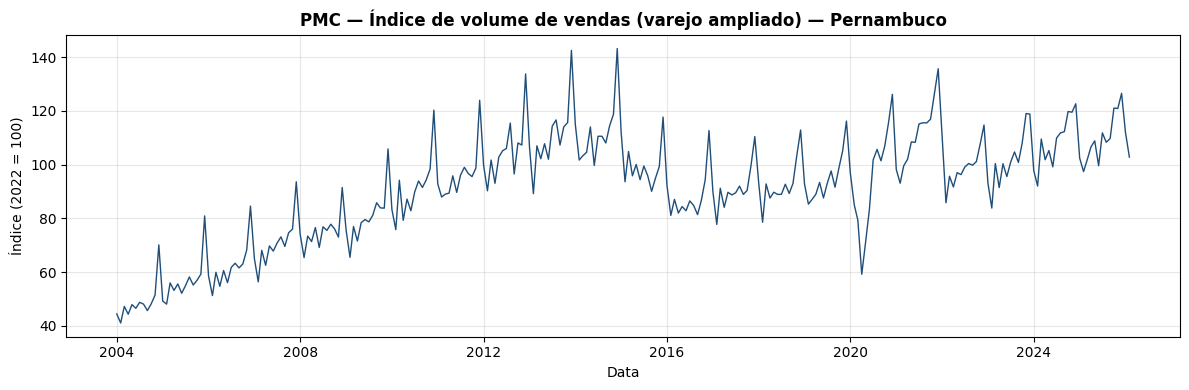

In [4]:
serie = df_sf.set_index('ds')['y']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie.index, serie.values, color='#1f4e79', linewidth=1.0)
ax.set_title(f'PMC — Índice de volume de vendas (varejo ampliado) — {MINHA_UF}', fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Índice (2022 = 100)')
plt.tight_layout()
plt.show()

### Decomposição STL

Separa a série em **tendência**, **sazonalidade anual** e **resíduo**.

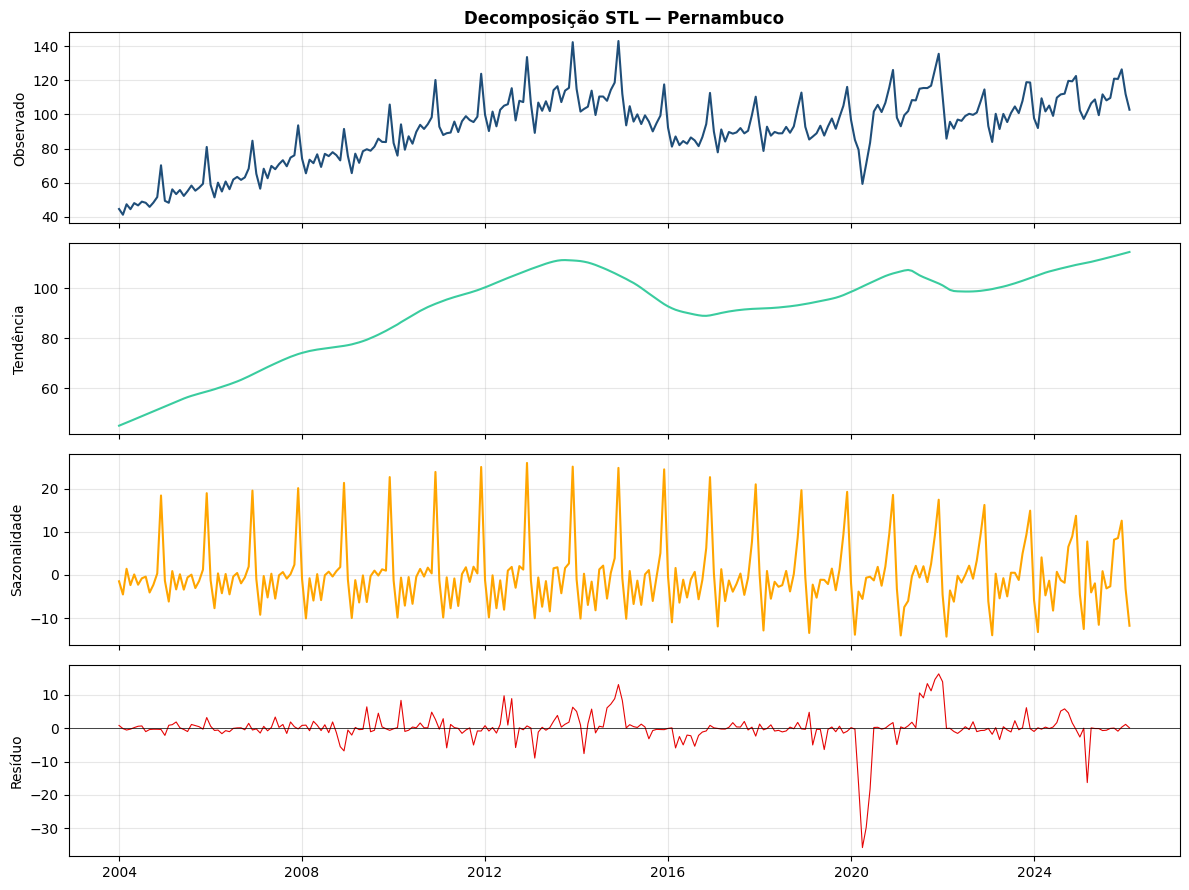

In [5]:
stl = STL(serie, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(serie.index, stl.observed, color='#1f4e79'); axes[0].set_ylabel('Observado')
axes[1].plot(serie.index, stl.trend, color='#3ACC9F', linewidth=1.5); axes[1].set_ylabel('Tendência')
axes[2].plot(serie.index, stl.seasonal, color='#FFA500'); axes[2].set_ylabel('Sazonalidade')
axes[3].plot(serie.index, stl.resid, color='#E50505', linewidth=0.8); axes[3].set_ylabel('Resíduo')
axes[3].axhline(0, color='black', linewidth=0.5)
axes[0].set_title(f'Decomposição STL — {MINHA_UF}', fontweight='bold')
plt.tight_layout()
plt.show()

### Sazonalidade — boxplot por mês

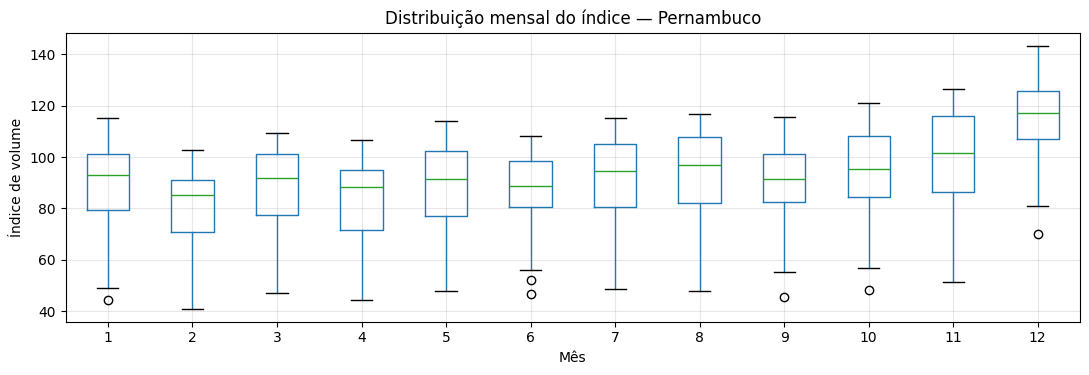

In [6]:
df_box = df_sf.copy()
df_box['mes'] = df_box['ds'].dt.month

fig, ax = plt.subplots(figsize=(11, 4))
df_box.boxplot(column='y', by='mes', ax=ax, grid=True)
ax.set_title(f'Distribuição mensal do índice — {MINHA_UF}')
ax.set_xlabel('Mês')
ax.set_ylabel('Índice de volume')
plt.suptitle('')
plt.tight_layout()
plt.show()

### ACF e PACF da série original

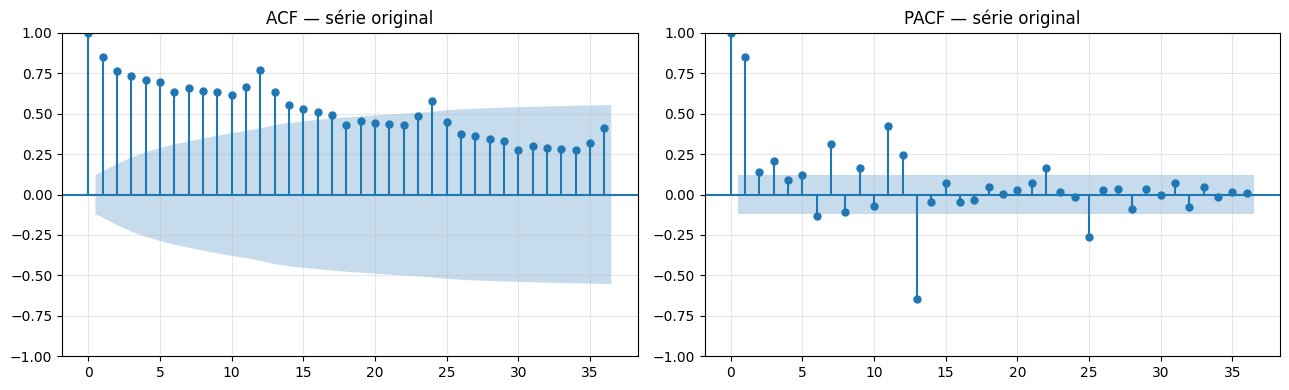

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(serie, lags=36, ax=axes[0])
axes[0].set_title('ACF — série original')
plot_pacf(serie, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF — série original')
plt.tight_layout()
plt.show()

### Diferenciação

Aplicamos:
- 1ª diferença regular: $\Delta y_t = y_t - y_{t-1}$ (remove tendência estocástica).
- 1ª diferença sazonal: $\Delta_{12} y_t = y_t - y_{t-12}$ (remove sazonalidade).

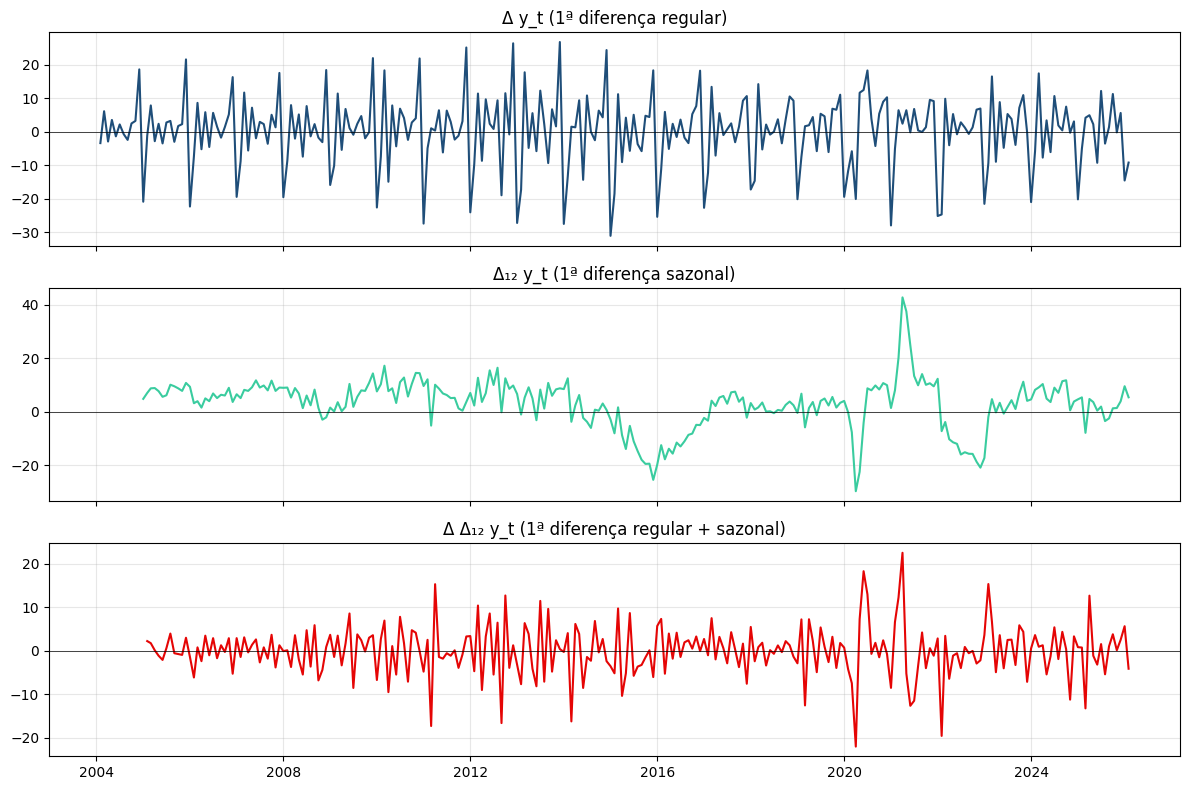

In [8]:
serie_d1 = serie.diff().dropna()
serie_d12 = serie.diff(12).dropna()
serie_d1_d12 = serie.diff().diff(12).dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(serie_d1, color='#1f4e79'); axes[0].set_title('Δ y_t (1ª diferença regular)'); axes[0].axhline(0, color='black', linewidth=0.5)
axes[1].plot(serie_d12, color='#3ACC9F'); axes[1].set_title('Δ₁₂ y_t (1ª diferença sazonal)'); axes[1].axhline(0, color='black', linewidth=0.5)
axes[2].plot(serie_d1_d12, color='#E50505'); axes[2].set_title('Δ Δ₁₂ y_t (1ª diferença regular + sazonal)'); axes[2].axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

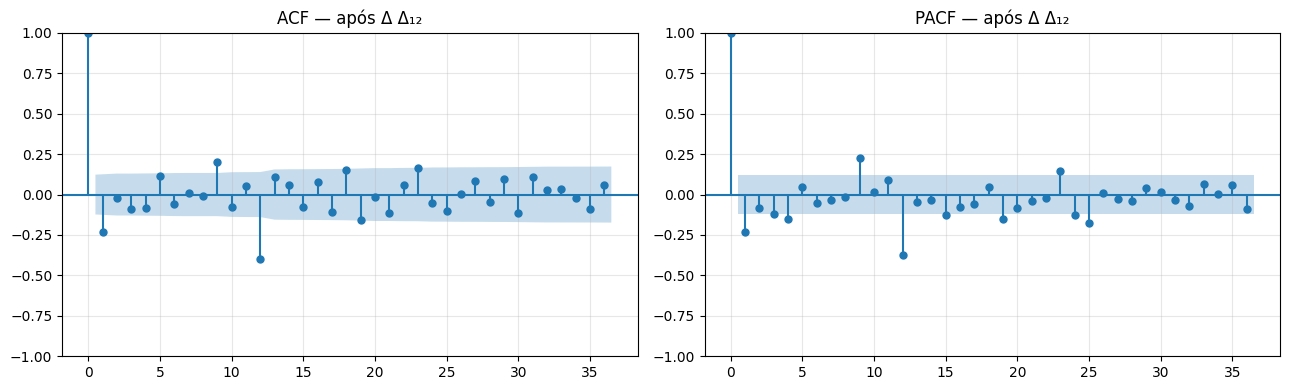

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(serie_d1_d12, lags=36, ax=axes[0])
axes[0].set_title('ACF — após Δ Δ₁₂')
plot_pacf(serie_d1_d12, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF — após Δ Δ₁₂')
plt.tight_layout()
plt.show()

## Testes de raiz unitária e estimativa de diferenciações

In [10]:
def teste_adf(x, label=''):
    stat, p, *_ = adfuller(x, autolag='AIC')
    veredito = 'estacionária ✅' if p < 0.05 else 'NÃO estacionária ⚠️'
    print(f'ADF {label:>22} → estatística={stat:.3f}  p-valor={p:.4f}  → {veredito}')
    return p

def teste_kpss(x, label=''):
    stat, p, *_ = kpss(x, regression='c', nlags='auto')
    veredito = 'NÃO estacionária ⚠️' if p < 0.05 else 'estacionária ✅'
    print(f'KPSS{label:>22} → estatística={stat:.3f}  p-valor={p:.4f}  → {veredito}')
    return p

print('### ADF — H0: existe raiz unitária (não-estacionária)')
teste_adf(serie, 'série original')
teste_adf(serie_d1, 'após Δ')
teste_adf(serie_d1_d12, 'após Δ Δ₁₂')

print('\n### KPSS — H0: série é estacionária')
teste_kpss(serie, 'série original')
teste_kpss(serie_d1, 'após Δ')
teste_kpss(serie_d1_d12, 'após Δ Δ₁₂')

### ADF — H0: existe raiz unitária (não-estacionária)
ADF         série original → estatística=-2.140  p-valor=0.2287  → NÃO estacionária ⚠️
ADF                 após Δ → estatística=-4.064  p-valor=0.0011  → estacionária ✅
ADF             após Δ Δ₁₂ → estatística=-5.615  p-valor=0.0000  → estacionária ✅

### KPSS — H0: série é estacionária
KPSS        série original → estatística=1.572  p-valor=0.0100  → NÃO estacionária ⚠️
KPSS                após Δ → estatística=0.205  p-valor=0.1000  → estacionária ✅
KPSS            após Δ Δ₁₂ → estatística=0.032  p-valor=0.1000  → estacionária ✅


/var/folders/1m/46ym1hyn7h7_5k_lbfvp8t080000gn/T/ipykernel_3897/206892139.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, *_ = kpss(x, regression='c', nlags='auto')
/var/folders/1m/46ym1hyn7h7_5k_lbfvp8t080000gn/T/ipykernel_3897/206892139.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x, regression='c', nlags='auto')
/var/folders/1m/46ym1hyn7h7_5k_lbfvp8t080000gn/T/ipykernel_3897/206892139.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x, regression='c', nlags='auto')


np.float64(0.1)

In [11]:
d_adf = ndiffs(serie, test='adf')
d_kpss = ndiffs(serie, test='kpss')
D_ch = nsdiffs(serie, m=12, test='ch')
D_ocsb = nsdiffs(serie, m=12, test='ocsb')

print('Estimativa de número de diferenças')
print(f'  ndiffs (ADF):  d = {d_adf}')
print(f'  ndiffs (KPSS): d = {d_kpss}')
print(f'  nsdiffs (CH):   D = {D_ch}')
print(f'  nsdiffs (OCSB): D = {D_ocsb}')

Estimativa de número de diferenças
  ndiffs (ADF):  d = 1
  ndiffs (KPSS): d = 1
  nsdiffs (CH):   D = 0
  nsdiffs (OCSB): D = 0


## Modelagem — AutoARIMA(season_length=12)

Vamos deixar o `AutoARIMA` da Nixtla (`statsforecast`) selecionar `(p,d,q)(P,D,Q)_12` minimizando AICc.

In [12]:
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='MS',
    n_jobs=1,
)
sf.fit(df=df_sf)

fitted = sf.fitted_[0, 0]
modelo = fitted.model_

ordem = modelo['arma']  # (p, q, P, Q, m, d, D)
p, q, P, Q, m, d, D = ordem
print(f'Modelo selecionado: SARIMA({p},{d},{q})({P},{D},{Q})[{m}]')
print(f'AICc: {modelo["aicc"]:.2f}   AIC: {modelo["aic"]:.2f}   BIC: {modelo["bic"]:.2f}')
print(f'σ²: {modelo["sigma2"]:.4f}')

Modelo selecionado: SARIMA(1,1,1)(0,1,2)[12]
AICc: 1518.66   AIC: 1518.41   BIC: 1536.08
σ²: 22.2898


## Diagnóstico dos resíduos

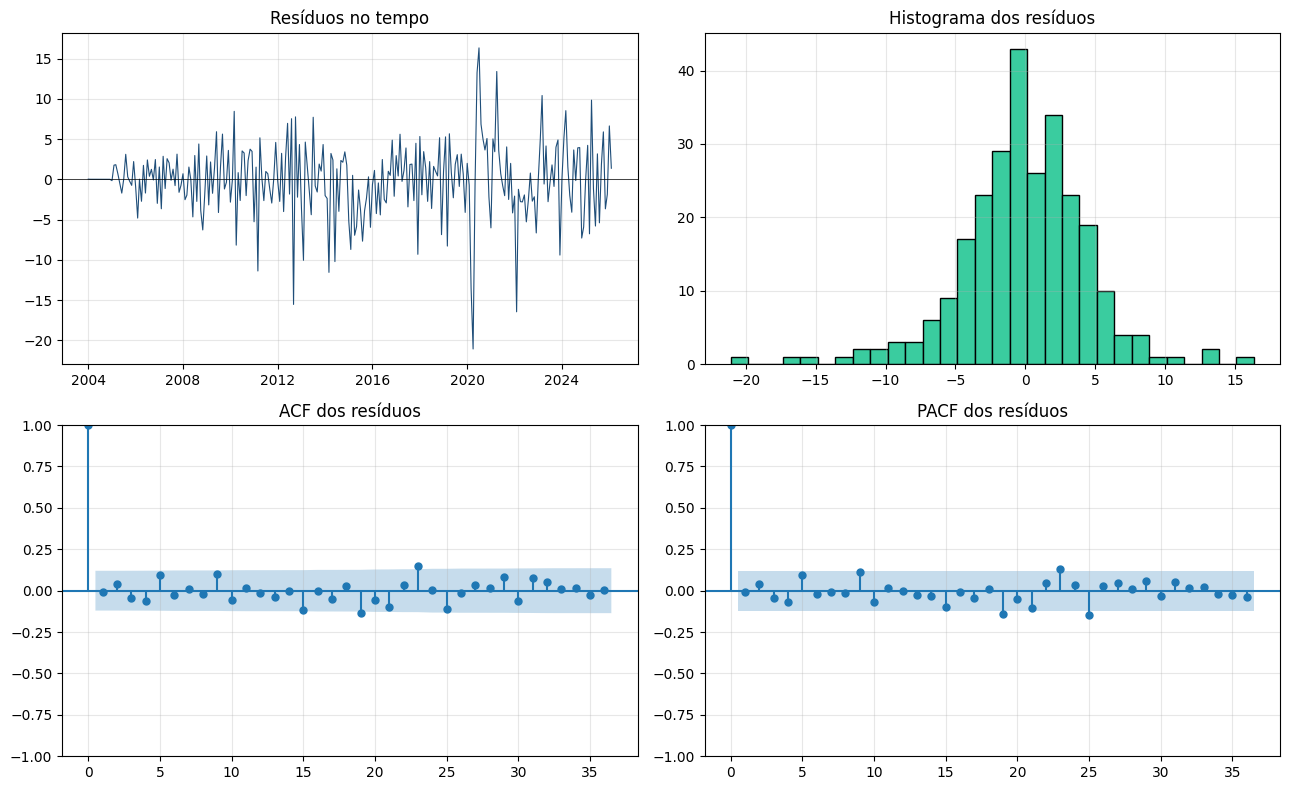

In [13]:
residuos = pd.Series(modelo['residuals'], index=df_sf['ds']).dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(residuos.index, residuos.values, color='#1f4e79', linewidth=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.5)
axes[0, 0].set_title('Resíduos no tempo')

axes[0, 1].hist(residuos, bins=30, color='#3ACC9F', edgecolor='black')
axes[0, 1].set_title('Histograma dos resíduos')

plot_acf(residuos, lags=36, ax=axes[1, 0])
axes[1, 0].set_title('ACF dos resíduos')

plot_pacf(residuos, lags=36, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF dos resíduos')

plt.tight_layout()
plt.show()

In [14]:
lb = acorr_ljungbox(residuos, lags=[12, 24, 36], return_df=True)
print('Teste de Ljung-Box (H0: ausência de autocorrelação nos resíduos)')
print(lb.round(4))

from scipy import stats
jb_stat, jb_p = stats.jarque_bera(residuos)
print(f'\nJarque-Bera (normalidade): estatística={jb_stat:.3f}  p-valor={jb_p:.4f}')

Teste de Ljung-Box (H0: ausência de autocorrelação nos resíduos)
    lb_stat  lb_pvalue
12   8.5995     0.7367
24  30.0040     0.1846
36  39.8890     0.3013

Jarque-Bera (normalidade): estatística=102.747  p-valor=0.0000


## Previsão · 24 meses à frente

Geramos previsão pontual e intervalos de **80 %** e **95 %**.

In [15]:
fcst = sf.predict(h=24, level=[80, 95])
fcst.head()

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
0,Pernambuco,2026-03-01,110.135431,100.882016,104.084948,116.185914,119.388846
1,Pernambuco,2026-04-01,107.371947,95.985661,99.926855,114.817040,118.758234
2,Pernambuco,2026-05-01,111.921305,99.265904,103.646383,120.196227,124.576706
3,Pernambuco,2026-06-01,107.126095,93.499499,98.216143,116.036048,120.752692
4,Pernambuco,2026-07-01,115.894079,101.429386,106.436125,125.352034,130.358773


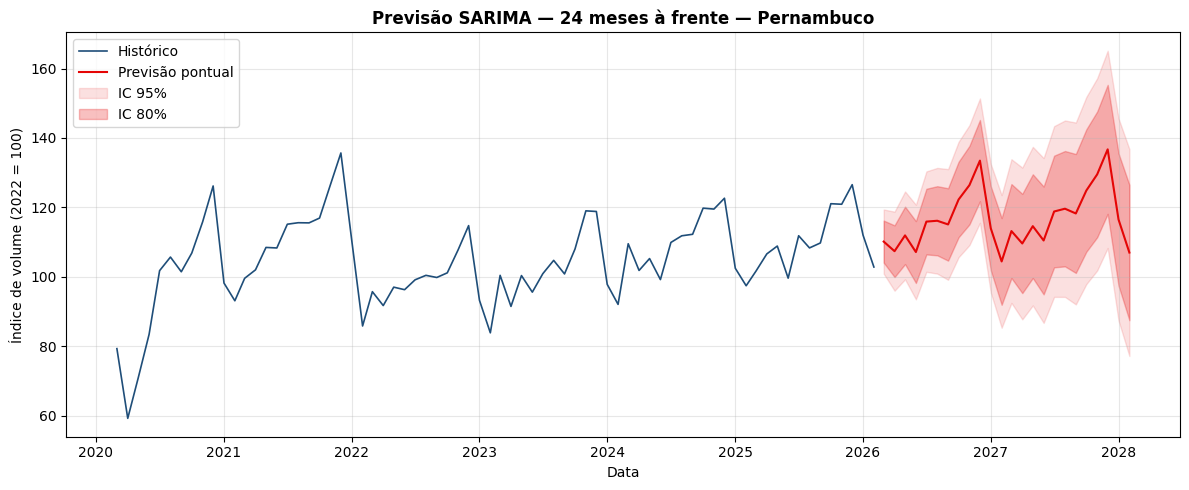

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
0,Pernambuco,2026-03-01,110.14,100.88,104.08,116.19,119.39
1,Pernambuco,2026-04-01,107.37,95.99,99.93,114.82,118.76
2,Pernambuco,2026-05-01,111.92,99.27,103.65,120.20,124.58
3,Pernambuco,2026-06-01,107.13,93.50,98.22,116.04,120.75
4,Pernambuco,2026-07-01,115.89,101.43,106.44,125.35,130.36
5,Pernambuco,2026-08-01,116.14,100.91,106.18,126.10,131.37
6,Pernambuco,2026-09-01,115.08,99.13,104.65,125.51,131.03
7,Pernambuco,2026-10-01,122.26,105.63,111.38,133.13,138.89
8,Pernambuco,2026-11-01,126.40,109.12,115.10,137.70,143.69
9,Pernambuco,2026-12-01,133.46,115.55,121.75,145.18,151.38


In [16]:
hist = df_sf.tail(72).copy()  # últimos 6 anos

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hist['ds'], hist['y'], color='#1f4e79', linewidth=1.2, label='Histórico')
ax.plot(fcst['ds'], fcst['AutoARIMA'], color='#E50505', linewidth=1.5, label='Previsão pontual')
ax.fill_between(fcst['ds'], fcst['AutoARIMA-lo-95'], fcst['AutoARIMA-hi-95'], color='#E50505', alpha=0.12, label='IC 95%')
ax.fill_between(fcst['ds'], fcst['AutoARIMA-lo-80'], fcst['AutoARIMA-hi-80'], color='#E50505', alpha=0.25, label='IC 80%')
ax.set_title(f'Previsão SARIMA — 24 meses à frente — {MINHA_UF}', fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Índice de volume (2022 = 100)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fcst.head(12).round(2)

## Discussão

**1. O ACF/PACF da série original sugeriu sazonalidade? E tendência? Bate com o que você viu no gráfico de linha?**

Sim. O ACF da série de Pernambuco decai muito lentamente, com correlações fortes mesmo em lags altos — assinatura clássica de **tendência estocástica/não-estacionariedade**. Além disso, observam-se **picos nos lags múltiplos de 12** (12, 24, 36), confirmando **sazonalidade anual**. Isso é consistente com o gráfico de linha: trajetória ascendente até ~2014, retração nos anos 2015-2016 (recessão), recuperação posterior, queda abrupta em 2020 (pandemia) e oscilações regulares dentro de cada ano (festas de fim de ano puxam o volume para cima). Os testes confirmam o diagnóstico: ADF não rejeita raiz unitária na série original (p = 0,23) e KPSS rejeita estacionariedade (p ≤ 0,01); após uma diferença regular ambos passam a apontar estacionariedade.

**2. Quantas diferenças (regular e sazonal) o AutoARIMA aplicou? E os componentes AR/MA? Conseguiu observar isso no ACF/PACF?**

O modelo escolhido foi **SARIMA(1,1,1)(0,1,2)[12]**: **d = 1** diferença regular e **D = 1** diferença sazonal, com **AR(1) + MA(1)** na parte regular e **MA(2) sazonal** (sem AR sazonal). O `ndiffs` apontou d = 1 (ADF e KPSS concordam), enquanto `nsdiffs` (CH/OCSB) apontou D = 0 — o AutoARIMA, otimizando AICc, decidiu adicionar a diferença sazonal mesmo assim, sinal de que os picos sazonais residuais ainda eram relevantes. Isso é coerente com o ACF/PACF da série original (picos claros em 12, 24, 36) e com o ACF/PACF após Δ Δ₁₂, que mostra um corte mais abrupto e a estrutura MA-curta que o modelo capturou.

**3. Os resíduos parecem white noise? Algum padrão remanescente sazonal?**

Sim, em larga medida. O **Ljung-Box** não rejeita H₀ em nenhum dos lags testados (p = 0,74 em 12, p = 0,18 em 24, p = 0,30 em 36) → não há evidência de autocorrelação remanescente, inclusive sazonal. ACF e PACF dos resíduos ficam quase totalmente dentro das bandas de confiança. O **Jarque-Bera** rejeita normalidade (p ≈ 0), efeito esperado por causa dos outliers de 2020 (choque da pandemia) — visíveis no gráfico de resíduos no tempo e no histograma. Isso não invalida a previsão pontual, mas amplia ligeiramente os intervalos.

**4. A previsão pareceu razoável visualmente?**

Sim. A previsão pontual replica o padrão sazonal anual visto no histórico (picos em novembro/dezembro, vales no início do ano), mantém o nível compatível com os últimos meses observados e os intervalos abrem de forma controlada — IC 80 % apertado nos primeiros meses e IC 95 % alargando à medida que o horizonte cresce, comportamento esperado em SARIMA.

**5. Que outras UFs dariam um SARIMA bem diferente do seu (e por quê)?**

Estados com **perfil econômico menos diversificado** ou **muito sensíveis a choques específicos** tendem a produzir modelos bem diferentes:

- **Roraima e Amapá**: mercados pequenos, séries mais ruidosas, sazonalidade menos definida — provável SARIMA com componentes mais simples e intervalos largos.
- **Espírito Santo**: forte peso de commodities (minério, petróleo); choques externos (Vale/Samarco em 2015, COVID) deformam tendência e podem exigir ordens diferentes.
- **São Paulo / Distrito Federal**: economias diversificadas, tendência mais suave e sazonalidade muito previsível, geralmente bem capturadas por SARIMAs parcimoniosos com intervalos estreitos.
- **Mato Grosso / Goiás**: agronegócio gera ciclos atípicos (entressafra/colheita) que misturam padrões anuais e podem demandar mais termos sazonais ou abordagens MSTL.